# Bike Rental Demand — Data Understanding and Preparation

Exploratory analysis and preparation of daily bicycle-rental data, including calendar, weather and demand variables. The notebook documents the decisions that produce the modelling dataset used by the later experiments.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**CONSTANTS**


In [2]:
FILE_NAME = 'data/bike_day_v2.xlsx'


**IMPORTS**


In [4]:
import pandas as pd
import hvplot.pandas

import holoviews as hv
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import umap

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from pandas.plotting import scatter_matrix
from scipy.spatial.distance import euclidean
from hvplot.plotting import scatter_matrix


**OPTIONS**


**HELPERS**


In [8]:
def categorical_histogram(df, column, height=2000, width=1000, xrotation=45):
    histogram = df[column].value_counts().hvplot.bar(
        height=height,
        width=width,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel='',
        ylabel='',
    )

    return histogram.opts(
        fontsize={'title': 16, 'labels': 10, 'xticks': 8, 'yticks': 8},
        xrotation=xrotation,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left',
    )


In [9]:
def line_chart(df, column, height=1200, width=1000):
    histogram = df[column].value_counts().hvplot.line(
        height=height,
        width=width,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel='',
        ylabel='',
    )

    return histogram.opts(
        fontsize={'title': 16, 'labels': 10, 'xticks': 8, 'yticks': 8},
        xrotation=45,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left',
    )


In [10]:
def numerical_histogram(df, column, height=400, bins=30):
    histogram = df[column].hvplot.hist(
        bins=bins,
        height=height,
        width=600,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel=column,
        ylabel='Frequency',
    )

    return histogram.opts(
        fontsize={'title': 16, 'labels': 10, 'xticks': 8, 'yticks': 8},
        xrotation=45,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left'
        )


In [11]:
def numerical_boxplot(df, column, height=400, width=600):
    # Convert height and width from "pixels" to "inches" (roughly)
    fig, ax = plt.subplots(figsize=(width / 100, height / 100))

    ax.boxplot(
        df[column],
        patch_artist=True,             # Enables facecolor on the boxes
        boxprops=dict(facecolor='#1f77b4')
    )

    ax.set_title(f'Box Plot // Column: {column}')
    ax.set_ylabel(column)

    plt.show()


In [2]:
def spectral_plot(df_input, column_discriminatory, column_data, height=800, width=800):
    # Create the data
    df = df_input[[column_data, column_discriminatory]]
    
    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
    g = sns.FacetGrid(df, row=column_discriminatory, hue=column_discriminatory, aspect=15, height=.5, palette=pal)
    
    # Draw the densities in a few steps
    g.map(sns.kdeplot, column_data,
          bw_adjust=.5, clip_on=False,
          fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, column_data, clip_on=False, color="w", lw=2, bw_adjust=.5)
    
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
    
    
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)
    
    
    g.map(label, column_data)
    
    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.25)
    
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)


# 1. Data Understanding
## 1.1 Data Loading and Initial Inspection


In [14]:
df_bike = pd.read_excel('./Data/Raw/bike_day_v2.xlsx')


## Dataset description

- **instant**: record index 
- **dteday** : date
- **season** : season (1:springer, 2:summer, 3:fall, 4:winter)
- **yr** : year (0: 2011, 1:2012)
- **mnth** : month ( 1 to 12)
- **holiday** : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
- **weekday** : day of the week
- **workingday** : if day is neither weekend nor holiday is 1, otherwise is 0
- **schoolday** : if day is a normal school day is 1, otherwise is 0
- **weathersit** : 
	- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
	- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
	- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
	- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- **temp** : Normalized temperature in Celsius. The values are divided to 41 (max)
- **atemp**: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
- **hum**: Normalized humidity. The values are divided to 100 (max)
- **windspeed**: Normalized wind speed. The values are divided to 67 (max)
- **casual**: count of casual users -> NOT USE because of leakage - highly correlated with the target --> EXCEPT HISTORICAL DATA that we already know at 3pm the day before, by creating a new variable - but we need to be careful with what changed between the time of the historical data and now
- **registered**: count of registered users -> NOT USE because of leakage - highly correlated with the target --> EXCEPT HISTORICAL DATA that we already know at 3pm the day before, by creating a new variable
- **cnt**: count of total rental bikes including both casual and registered --> **what we want to predict**


**Goal**: predict everyday at 15h00 the total number of bikes they will rent the following day  
**Observations**: Our target variable is `cnt`, which is the total amount of bikes rented, combining `casual` and `registered`. This means that these 2 variables are highly correlated with the target variable, so we shouldn't use them to avoid leakage. However, if necessary, we can create a new variable using information from these from a specific time in the past, but always considering what might have changed between now and then.


In [17]:
df_bike.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [18]:
df_bike.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     732 non-null    int64         
 1   dteday      732 non-null    datetime64[ns]
 2   season      732 non-null    int64         
 3   yr          732 non-null    int64         
 4   mnth        732 non-null    int64         
 5   holiday     732 non-null    int64         
 6   weekday     730 non-null    float64       
 7   workingday  732 non-null    int64         
 8   schoolday   454 non-null    float64       
 9   weathersit  732 non-null    int64         
 10  temp        732 non-null    float64       
 11  atemp       732 non-null    float64       
 12  hum         732 non-null    float64       
 13  windspeed   732 non-null    float64       
 14  casual      732 non-null    int64         
 15  registered  732 non-null    int64         
 16  cnt         732 non-null  

In [19]:
df_bike.describe(include='all')


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,732.000000,732,732.000000,732.000000,732.000000,732.000000,730.000000,732.000000,454.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.352459,2012-01-01 08:27:32.459016448,2.497268,0.501366,6.523224,0.028689,3.002740,0.683060,0.460352,1.394809,0.495539,0.474506,0.627722,0.204019,851.334699,3658.765027,4510.099727
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.750000,2011-07-02 18:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.337292,0.337891,0.519792,0.134950,315.750000,2499.000000,3157.500000
50%,366.500000,2012-01-01 12:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,0.000000,1.000000,0.499167,0.487364,0.626250,0.180975,717.000000,3664.500000,4548.500000
75%,549.250000,2012-07-02 06:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,1.000000,2.000000,0.655208,0.608289,0.730104,0.233376,1097.750000,4792.750000,5978.500000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,1.000000,3.000000,0.861667,0.840896,0.972500,10.234234,3410.000000,6946.000000,8714.000000
std,211.236679,NaN,1.110203,0.500340,3.450769,0.167044,2.004793,0.465602,0.498975,0.544718,0.182973,0.162902,0.142408,0.379164,691.452652,1560.765887,1942.128645


**Notes**
* The dataset has 17 variables, divided by type:
  * 1 datetime - `dteday`
  * 6 floats - `weekday`, `schoolday`, `temp`, `atemp`, `hum`, `windspeed`. Of these, `weekday` and `schoolday` are boolean variables, need to be changed.
  * 10 int - `instant`, `season`, `yr`, `mnth`, `holiday`, `workingday`, `weathersit`, `casual`, `registered`, `cnt`. Of these, `instant`, `season`, `yr`, `mnth`, `weathersit` should be categorical, and `holiday` and `workingday` should be boolean. These need to be changed.

* There are 2 variables with missing values: `weekday` and `schoolday`. In `weekday`, there are only 2 missing values, so we can eliminate them. In `schoolday`, there are 278, which is around 38% of the data. This is a problematic situation.


In [21]:
# change variable type in the cases it is wrong
df_bike = df_bike.astype({'instant': object, 'season': object, 'yr': object, 'mnth': object, 'weathersit': object})
df_bike['dteday'] = pd.to_datetime(df_bike['dteday'])


In [22]:
df_bike.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     732 non-null    object        
 1   dteday      732 non-null    datetime64[ns]
 2   season      732 non-null    object        
 3   yr          732 non-null    object        
 4   mnth        732 non-null    object        
 5   holiday     732 non-null    int64         
 6   weekday     730 non-null    float64       
 7   workingday  732 non-null    int64         
 8   schoolday   454 non-null    float64       
 9   weathersit  732 non-null    object        
 10  temp        732 non-null    float64       
 11  atemp       732 non-null    float64       
 12  hum         732 non-null    float64       
 13  windspeed   732 non-null    float64       
 14  casual      732 non-null    int64         
 15  registered  732 non-null    int64         
 16  cnt         732 non-null  

In [23]:
df_bike.describe(include='all')


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,732.0,732,732.0,732.0,732.0,732.000000,730.000000,732.000000,454.000000,732.0,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
unique,731.0,NaN,4.0,2.0,12.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,624.0,NaN,3.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2.0,NaN,189.0,367.0,62.0,NaN,NaN,NaN,NaN,464.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2012-01-01 08:27:32.459016448,NaN,NaN,NaN,0.028689,3.002740,0.683060,0.460352,NaN,0.495539,0.474506,0.627722,0.204019,851.334699,3658.765027,4510.099727
min,NaN,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,NaN,2011-07-02 18:00:00,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,NaN,0.337292,0.337891,0.519792,0.134950,315.750000,2499.000000,3157.500000
50%,NaN,2012-01-01 12:00:00,NaN,NaN,NaN,0.000000,3.000000,1.000000,0.000000,NaN,0.499167,0.487364,0.626250,0.180975,717.000000,3664.500000,4548.500000
75%,NaN,2012-07-02 06:00:00,NaN,NaN,NaN,0.000000,5.000000,1.000000,1.000000,NaN,0.655208,0.608289,0.730104,0.233376,1097.750000,4792.750000,5978.500000
max,NaN,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,6.000000,1.000000,1.000000,NaN,0.861667,0.840896,0.972500,10.234234,3410.000000,6946.000000,8714.000000


In [24]:
df_bike.isna().sum()


instant         0
dteday          0
season          0
yr              0
mnth            0
holiday         0
weekday         2
workingday      0
schoolday     278
weathersit      0
temp            0
atemp           0
hum             0
windspeed       0
casual          0
registered      0
cnt             0
dtype: int64

**NOTES**:
* In `instant`, there are 2 occurrences of 624. This could be a case of duplicated information. 
* The data is from the period between 01-01-2011 and 31-12-2012.
* The most common season is `fall`.


In [26]:
df_bike.loc[df_bike.instant.isin([624.0])]


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
623,624,2012-09-15,3,1,9,0,6.0,0,0.0,1,0.608333,0.585867,0.501667,0.247521,3160,5554,8714
624,624,2012-09-15,3,1,9,0,6.0,0,0.0,1,0.608333,0.585867,0.501667,0.247521,3160,5554,8714


In [27]:
df_bike = df_bike.drop_duplicates()


In [28]:
df_bike.describe(include='all')


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.0,731,731.0,731.0,731.0,731.000000,729.000000,731.000000,453.000000,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,731.0,NaN,4.0,2.0,12.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1.0,NaN,3.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1.0,NaN,188.0,366.0,62.0,NaN,NaN,NaN,NaN,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2012-01-01 00:00:00,NaN,NaN,NaN,0.028728,2.998628,0.683995,0.461369,NaN,0.495385,0.474354,0.627894,0.203959,848.176471,3656.172367,4504.348837
min,NaN,2011-01-01 00:00:00,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,NaN,2011-07-02 12:00:00,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,NaN,2012-01-01 00:00:00,NaN,NaN,NaN,0.000000,3.000000,1.000000,0.000000,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,NaN,2012-07-01 12:00:00,NaN,NaN,NaN,0.000000,5.000000,1.000000,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,NaN,2012-12-31 00:00:00,NaN,NaN,NaN,1.000000,6.000000,1.000000,1.000000,NaN,0.861667,0.840896,0.972500,10.234234,3410.000000,6946.000000,8714.000000


## 1.2 EDA: Univariate Analysis


`season` | category


In [31]:
counts_season = df_bike['season'].value_counts(dropna=False)
print(counts_season)


season
3    188
2    184
1    181
4    178
Name: count, dtype: int64


:Bars   [season]   (count)
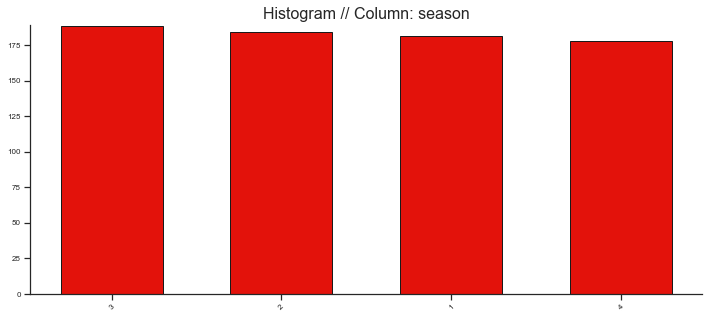

In [32]:
categorical_histogram(df_bike, 'season', height=400)


`yr` | category


In [34]:
counts_yr = df_bike['yr'].value_counts(dropna=False)
print(counts_yr)


yr
1    366
0    365
Name: count, dtype: int64


:Bars   [yr]   (count)
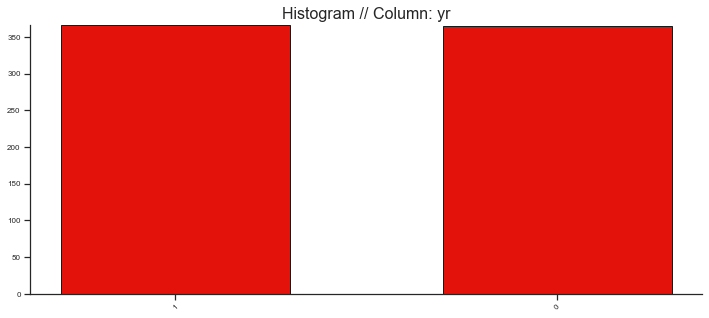

In [35]:
categorical_histogram(df_bike, 'yr', height=400)


`mnth` | category


In [37]:
counts_mnth = df_bike['mnth'].value_counts(dropna=False)
print(counts_mnth)


mnth
1     62
3     62
5     62
7     62
8     62
10    62
12    62
4     60
6     60
9     60
11    60
2     57
Name: count, dtype: int64


:Bars   [mnth]   (count)
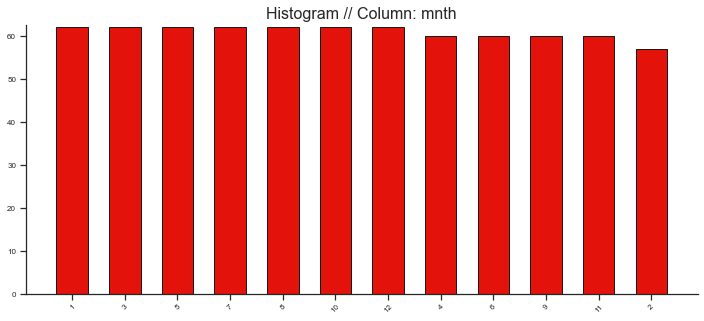

In [38]:
categorical_histogram(df_bike, 'mnth', height=400)


`holiday` |


In [40]:
counts_holiday = df_bike['holiday'].value_counts(dropna=False)
print(counts_holiday)


holiday
0    710
1     21
Name: count, dtype: int64


:Histogram   [holiday]   (holiday_count)
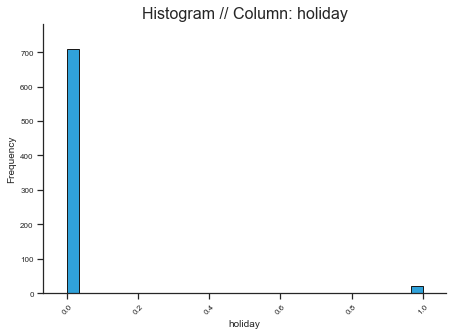

In [243]:
numerical_histogram(df_bike, 'holiday')


In [42]:
counts_holiday = df_bike['holiday'].value_counts(normalize=True, dropna=False) * 100
print(counts_holiday)


holiday
0    97.127223
1     2.872777
Name: proportion, dtype: float64


:Curve   [dteday]   (holiday)
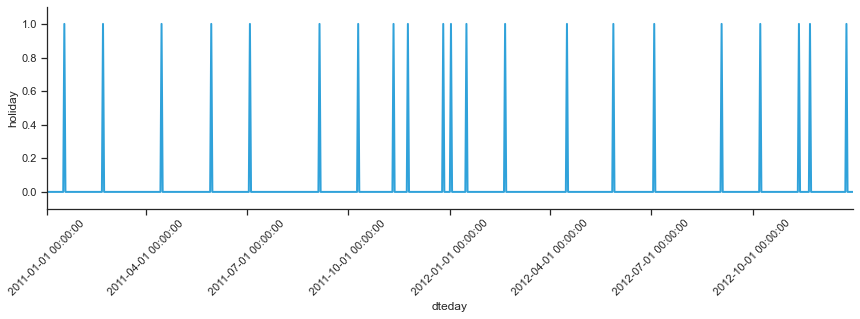

In [43]:
df_bike.hvplot.line(x='dteday', y='holiday', width=1200, rot=45)


`weekday` |


In [45]:
counts = df_bike['weekday'].value_counts(dropna=False)
print(counts)


weekday
6.0    105
1.0    105
0.0    104
2.0    104
3.0    104
4.0    104
5.0    103
NaN      2
Name: count, dtype: int64


:Histogram   [weekday]   (weekday_count)
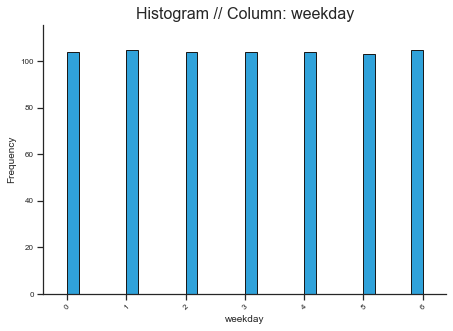

In [46]:
numerical_histogram(df_bike, 'weekday')


:Histogram   [weekday_filled]   (weekday_filled_count)
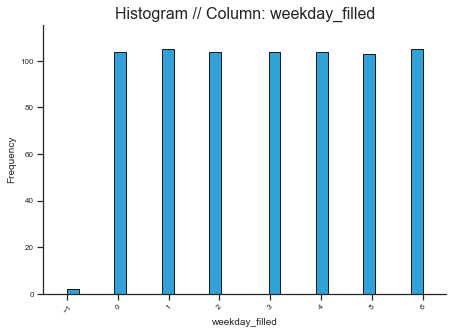

In [47]:
df_bike['weekday_filled'] = df_bike['weekday'].fillna(-1)
numerical_histogram(df_bike, 'weekday_filled')


`workingday`|


In [49]:
counts_workingday = df_bike['workingday'].value_counts(dropna=False)
print(counts_workingday)


workingday
1    500
0    231
Name: count, dtype: int64


:Histogram   [workingday]   (workingday_count)
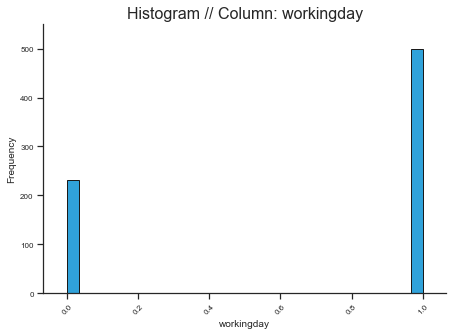

In [50]:
numerical_histogram(df_bike, 'workingday')


In [51]:
counts_workingday = df_bike['workingday'].value_counts(normalize=True, dropna=False) * 100
print(counts_workingday)


workingday
1    68.399453
0    31.600547
Name: proportion, dtype: float64


:Curve   [dteday]   (workingday)
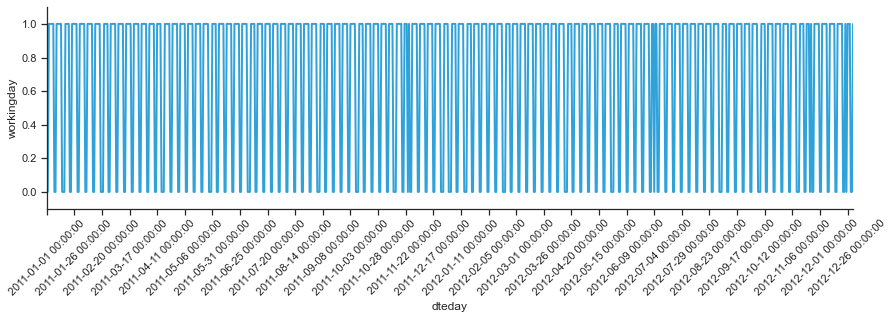

In [52]:
df_bike.hvplot.line(x='dteday', y='workingday', width=1200, rot=45, xticks=30)


:Scatter   [dteday]   (workingday)
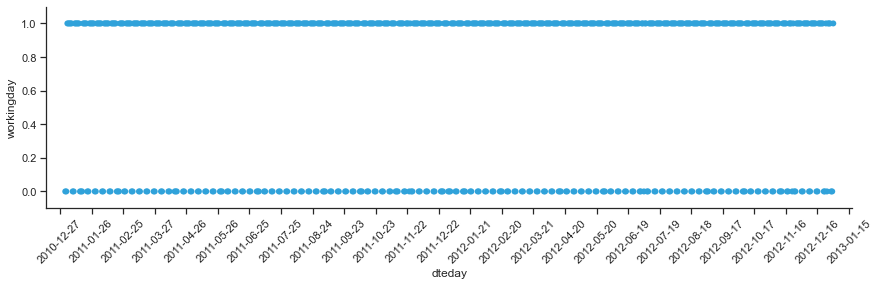

In [53]:
df_bike.hvplot.scatter(x='dteday', y='workingday', width=1200, rot=45, xticks=30)


`schoolday`|


In [55]:
counts = df_bike['schoolday'].value_counts(dropna=False)
print(counts)


schoolday
NaN    278
0.0    244
1.0    209
Name: count, dtype: int64


:Histogram   [schoolday_filled]   (schoolday_filled_count)
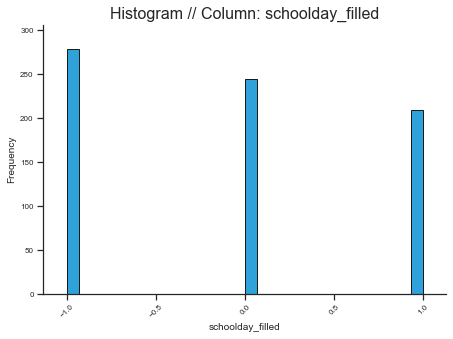

In [56]:
# I want to include the unknown values in the visualization to understand how it impacts the data
df_bike['schoolday_filled'] = df_bike['schoolday'].fillna(-1)
numerical_histogram(df_bike, 'schoolday_filled')


In [57]:
counts_schoolday_filled = df_bike['schoolday_filled'].value_counts(normalize=True, dropna=False) * 100
print(counts_schoolday_filled)


schoolday_filled
-1.0    38.030096
 0.0    33.378933
 1.0    28.590971
Name: proportion, dtype: float64


:Curve   [dteday]   (schoolday)
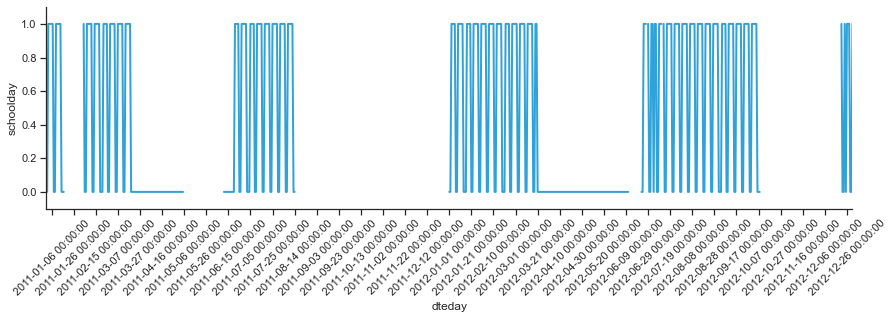

In [58]:
df_bike.hvplot.line(x='dteday', y='schoolday', width=1200, rot=45, xticks=40)


:Scatter   [dteday]   (schoolday)
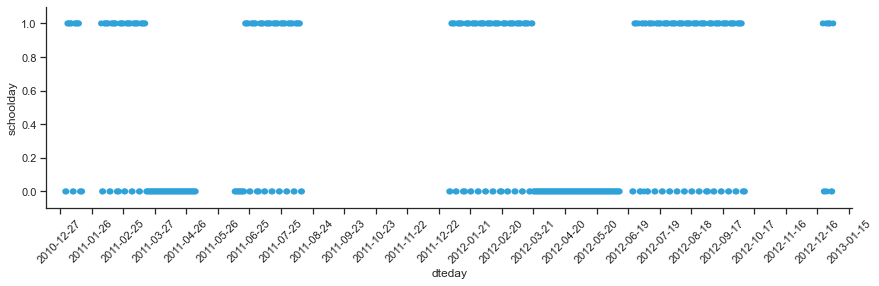

In [59]:
df_bike.hvplot.scatter(x='dteday', y='schoolday', width=1200, rot=45, xticks=30)


`weathersit`| categorical


In [61]:
counts_weathersit = df_bike['weathersit'].value_counts(dropna=False)
print(counts_weathersit)


weathersit
1    463
2    247
3     21
Name: count, dtype: int64


:Bars   [weathersit]   (count)
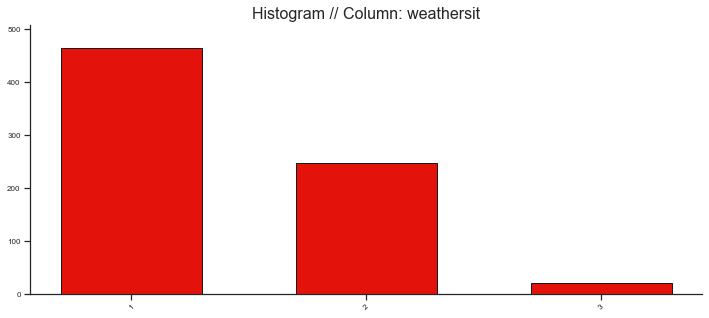

In [62]:
categorical_histogram(df_bike, 'weathersit', height=400)


:Curve   [dteday]   (weathersit)
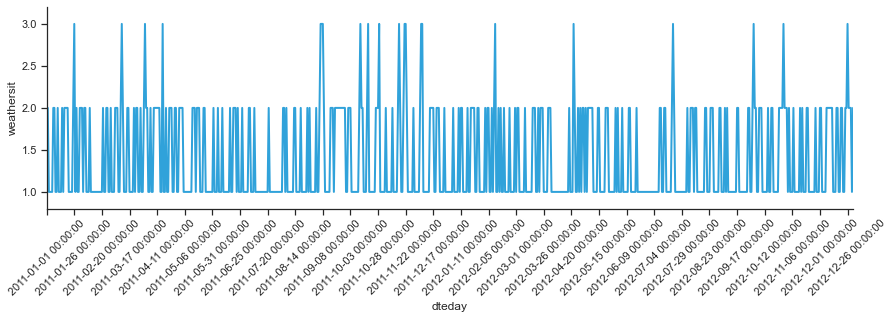

In [63]:
df_bike.hvplot.line(x='dteday', y='weathersit', width=1200, rot=45, xticks=30)


:Scatter   [dteday]   (weathersit)
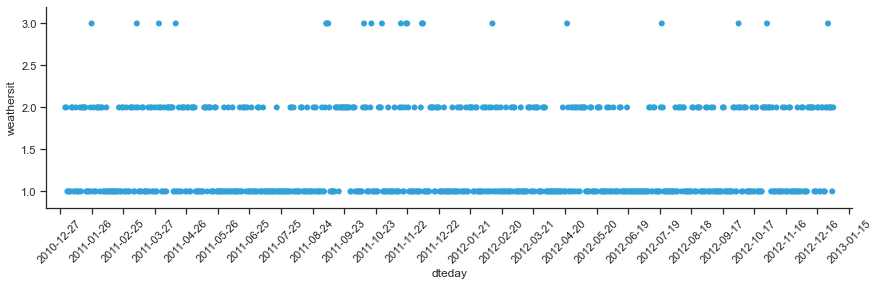

In [64]:
df_bike.hvplot.scatter(x='dteday', y='weathersit', width=1200, rot=45, xticks=30)


`temp`| numerical


In [66]:
counts_temp = df_bike['temp'].value_counts(dropna=False)
print(counts_temp)


temp
0.635000    5
0.265833    5
0.680000    4
0.710833    4
0.564167    4
           ..
0.669167    1
0.643333    1
0.707059    1
0.700000    1
0.215833    1
Name: count, Length: 499, dtype: int64


:Histogram   [temp]   (temp_count)
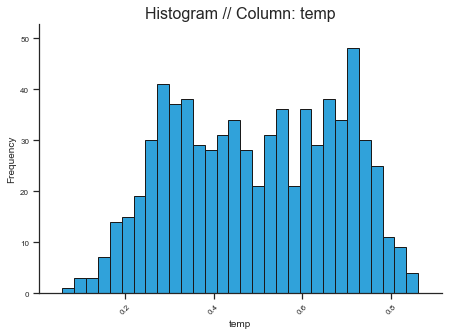

In [67]:
numerical_histogram(df_bike, 'temp', height=400)


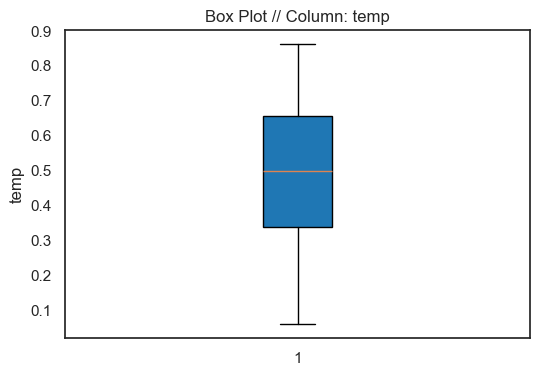

In [68]:
numerical_boxplot(df_bike, 'temp', height=400)


This distribution warrants further investigation before modelling.


In [70]:
# bin the temperature data into segments to better understand the temperature distribution, for the purposes of visualization
bins_temp = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels_temp = ["Very Low", "Low", "Moderate", "High", "Very High"]

df_bike["temp_segment"] = pd.cut(df_bike["temp"], bins=bins_temp, labels=labels_temp)


:Bars   [temp_segment]   (count)
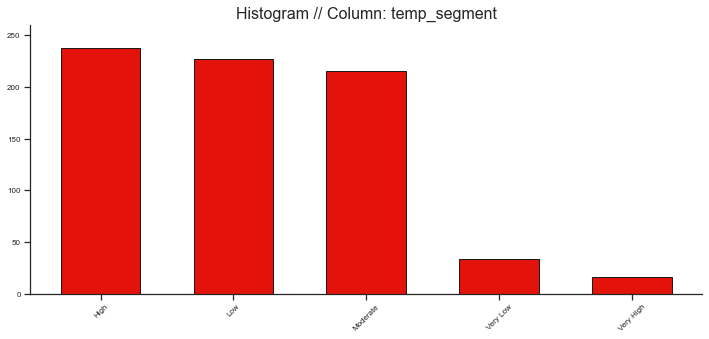

In [71]:
categorical_histogram(df_bike, 'temp_segment', height=400)


In [72]:
counts_temp_segment = df_bike['temp_segment'].value_counts(normalize=True, dropna=False) * 100
print(counts_temp_segment)


temp_segment
High         32.558140
Low          31.053352
Moderate     29.548564
Very Low      4.651163
Very High     2.188782
Name: proportion, dtype: float64


`atemp`| numerical


:Histogram   [atemp]   (atemp_count)
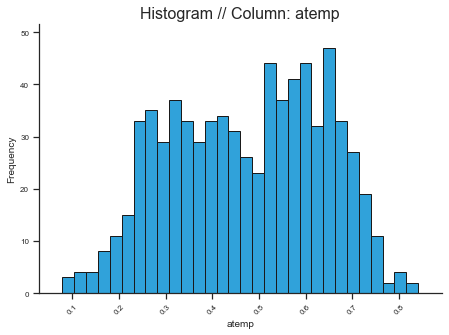

In [74]:
numerical_histogram(df_bike, 'atemp', height=400)


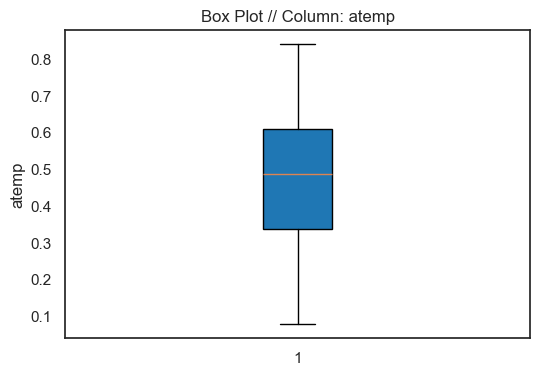

In [75]:
numerical_boxplot(df_bike, 'atemp', height=400)


In [76]:
# bin the temperature data into segments to better understand the temperature distribution, for the purposes of visualization
bins_atemp = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels_atemp = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
df_bike['atemp_segment'] = pd.cut(df_bike['atemp'], bins=bins_atemp, labels=labels_atemp)


:Bars   [atemp_segment]   (count)
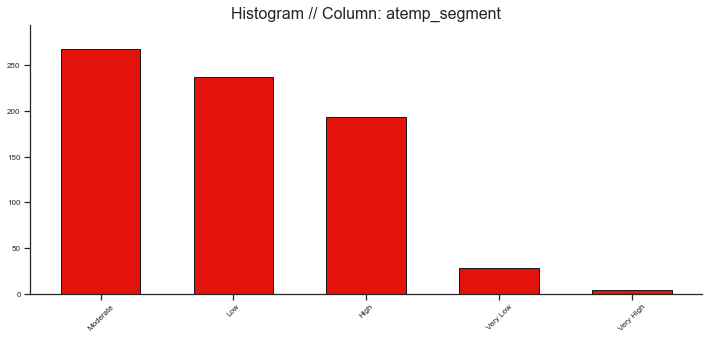

In [77]:
categorical_histogram(df_bike, 'atemp_segment', height=400)


In [78]:
counts_atemp_segment = df_bike['atemp_segment'].value_counts(normalize=True, dropna=False) * 100
print(counts_atemp_segment)


atemp_segment
Moderate     36.662107
Low          32.421341
High         26.538988
Very Low      3.830369
Very High     0.547196
Name: proportion, dtype: float64


The distribution of `temp` and `atemp` is very similar. We can choose one of them for analysis and drop the other. I would argue `atemp` makes more sense since the number that defines temperature is irrelevant if people feel cold or hot. So it's by real feel that people make decisions.


`hum`| numerical


:Histogram   [hum]   (hum_count)
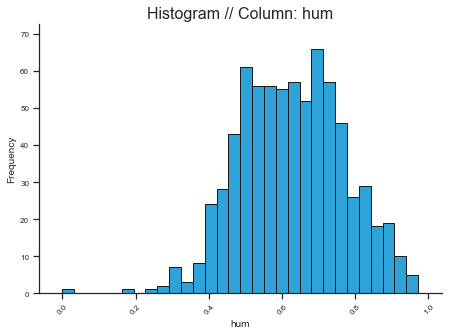

In [81]:
numerical_histogram(df_bike, 'hum', height=400)


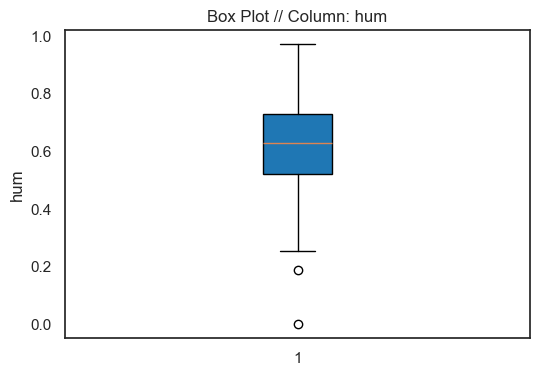

In [82]:
numerical_boxplot(df_bike, 'hum', height=400)


We have 2 outliers here: below 0.2


`windspeed`| numerical


:Histogram   [windspeed]   (windspeed_count)
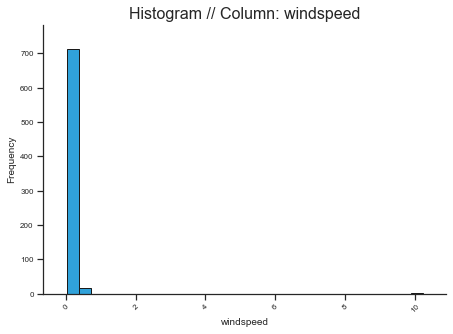

In [84]:
numerical_histogram(df_bike, 'windspeed', height=400)


In [85]:
counts_windspeed = df_bike['windspeed'].value_counts(dropna=False)


In [86]:
# bin the windspeed data into segments to better understand the wind speed distribution, for the purposes of visualization
bins_windspeed = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels_windspeed = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
df_bike['windspeed_segment'] = pd.cut(df_bike['windspeed'], bins=bins_windspeed, labels=labels_windspeed)


:Bars   [windspeed_segment]   (count)
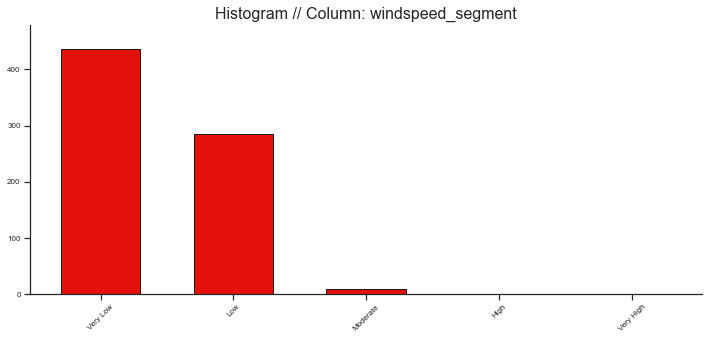

In [87]:
categorical_histogram(df_bike, 'windspeed_segment', height=400)


`casual`| numerical


:Histogram   [casual]   (casual_count)
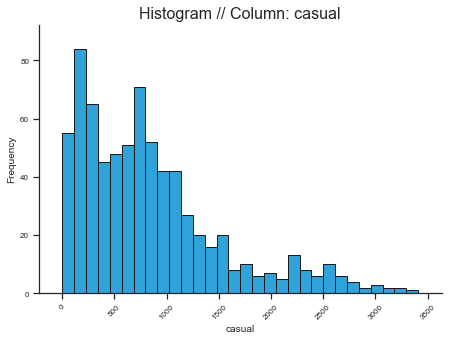

In [89]:
numerical_histogram(df_bike, 'casual', height=400)


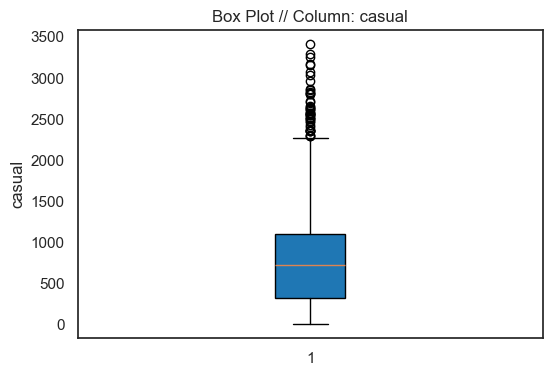

In [90]:
numerical_boxplot(df_bike, 'casual', height=400)


`registered`| numerical


:Histogram   [registered]   (registered_count)
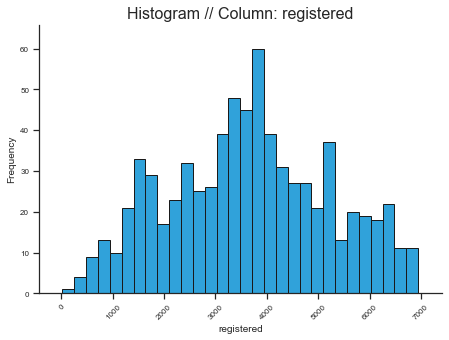

In [92]:
numerical_histogram(df_bike, 'registered', height=400)


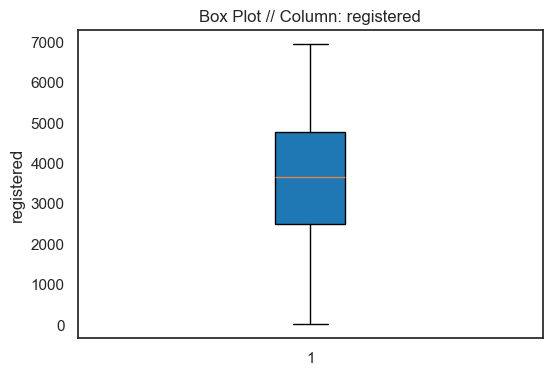

In [93]:
numerical_boxplot(df_bike, 'registered', height=400)


**NOTES**
* `holiday` seems useless since less than 3% of values are holidays.
* `schoolday` is a problem, maybe we can use `workingday` since children can't rent bikes by themselves - don't use schoolday?
* `windspeed` also seems to have no useful information, since it shows that people mostly rent bikes when there is low or no wind.


## 1.3 EDA: Multivariate Analysis


* compare the weather variables is probably useless, only maybe to help decide which one to use
* we can see `count` by `season`, `weekday`, `weathersit`, `atemp` and `workingday`.


In [97]:
sns_palette = sns.color_palette("husl", 4)


In [98]:
sns_palette_2 = sns.color_palette('viridis')


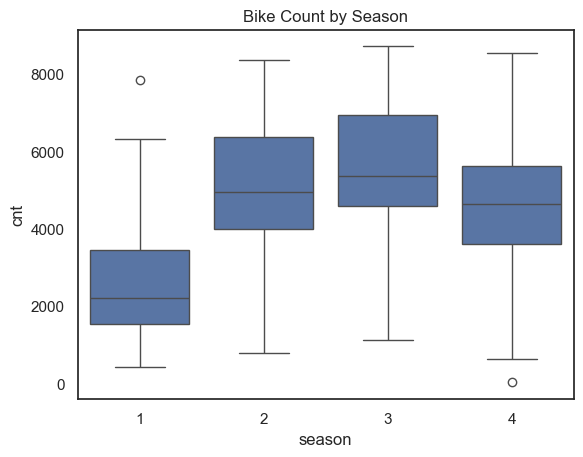

In [99]:
sns.boxplot(x='season', y='cnt', data=df_bike)
plt.title("Bike Count by Season")
plt.show()


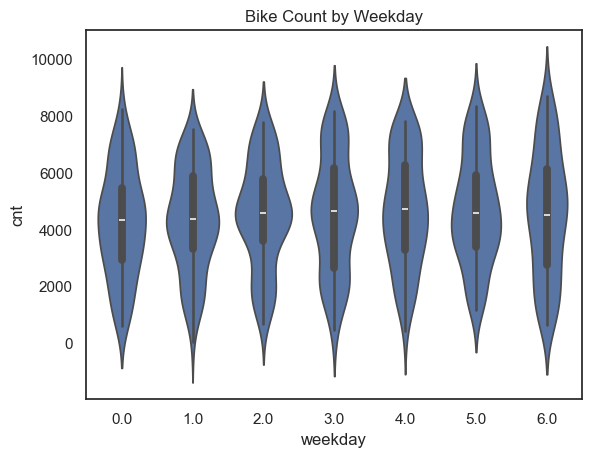

In [100]:
sns.violinplot(x='weekday', y='cnt', data=df_bike)
plt.title("Bike Count by Weekday")
plt.show()


<Axes: xlabel='weekday', ylabel='cnt'>

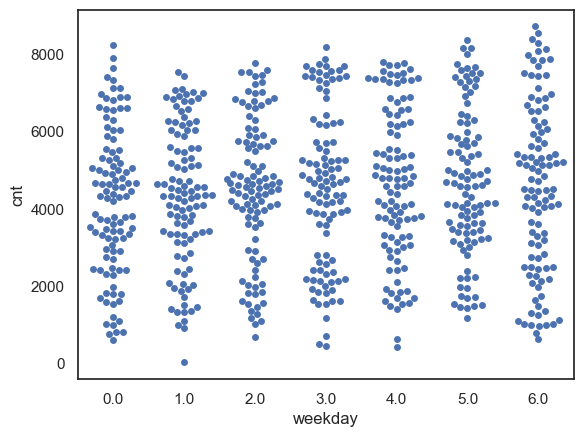

In [101]:
sns.swarmplot(data=df_bike, x="weekday", y="cnt", legend=True)


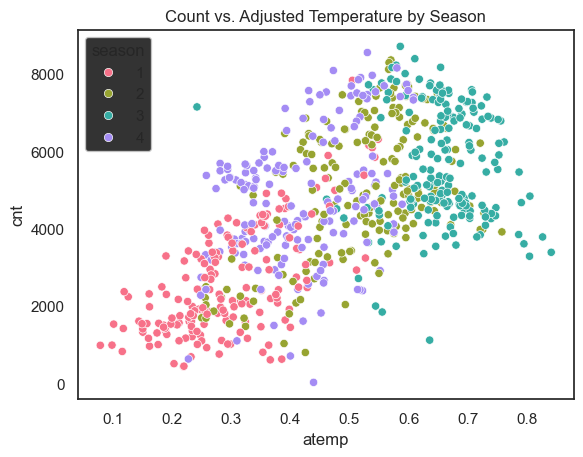

In [102]:
sns.scatterplot(x='atemp', y='cnt', hue='season', data=df_bike, palette=sns_palette)
plt.title("Count vs. Adjusted Temperature by Season")
plt.show()


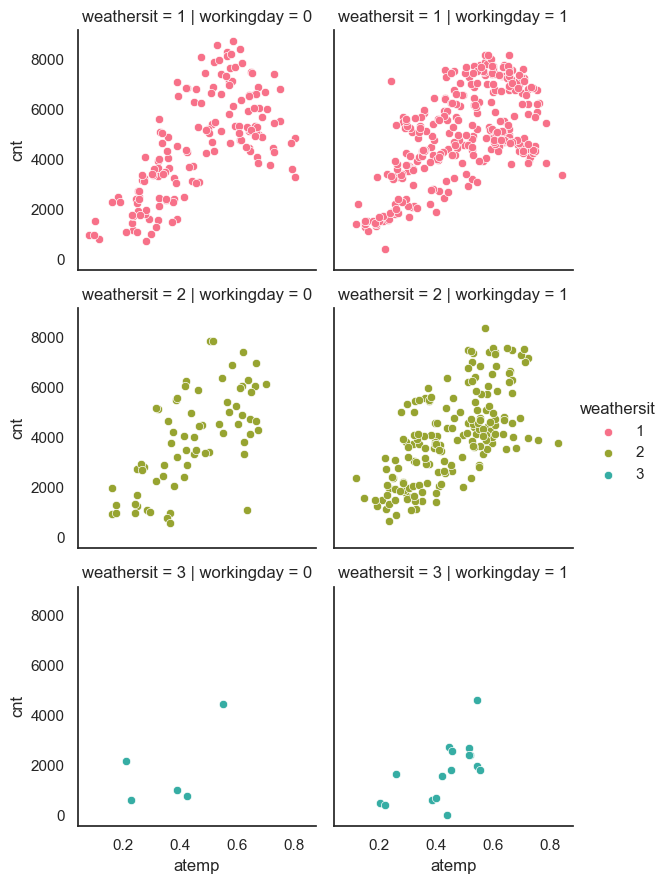

In [103]:
g = sns.FacetGrid(df_bike, col="workingday", row="weathersit", hue='weathersit', palette=sns_palette)
g.map(sns.scatterplot, "atemp", "cnt")
g.add_legend()
plt.show()


<Axes: xlabel='season', ylabel='cnt'>

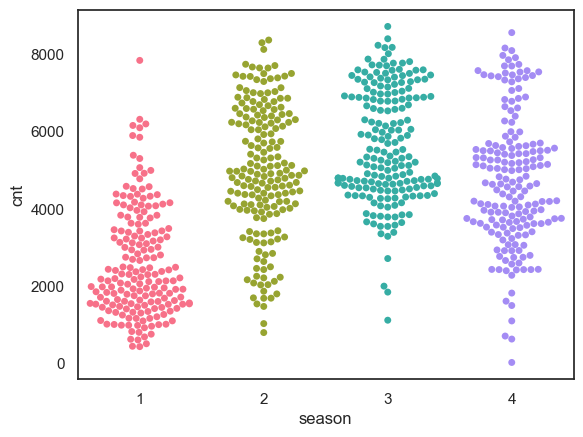

In [104]:
sns.swarmplot(data=df_bike, x="season", y="cnt", hue="season", legend=False, palette=sns_palette)


/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_96019/1580056790.py:1: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  sns.swarmplot(data=df_bike, x="weathersit", y="cnt", hue="weathersit", legend=True, palette=sns_palette)


<Axes: xlabel='weathersit', ylabel='cnt'>

/opt/anaconda3/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 5.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


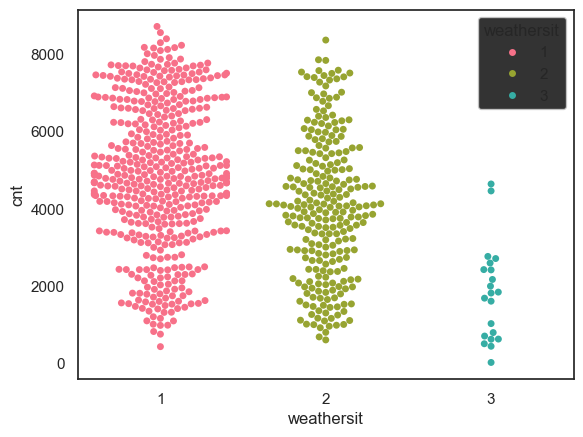

In [105]:
sns.swarmplot(data=df_bike, x="weathersit", y="cnt", hue="weathersit", legend=True, palette=sns_palette)


In [106]:
sns.color_palette("rocket", n_colors=12)


[(0.1125315, 0.06742194, 0.17414848),
 (0.22741085, 0.10140876, 0.25340813),
 (0.34940101, 0.11863987, 0.3138355),
 (0.47114798, 0.12098721, 0.34787978),
 (0.60444226, 0.10573912, 0.35820487),
 (0.73669146, 0.08704683, 0.33543669),
 (0.84335441, 0.14556683, 0.28480819),
 (0.91978131, 0.27526191, 0.24245973),
 (0.95001704, 0.42771398, 0.29244728),
 (0.96077819, 0.55997184, 0.39941173),
 (0.96479861, 0.68910113, 0.53756026),
 (0.9698028, 0.80981139, 0.70252255)]

In [107]:
df_bike[['atemp', 'mnth']]


,atemp,mnth
0,0.363625,1
1,0.353739,1
2,0.189405,1
3,0.212122,1
4,0.229270,1
...,...,...
727,0.226642,12
728,0.255046,12
729,0.242400,12
730,0.231700,12


/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


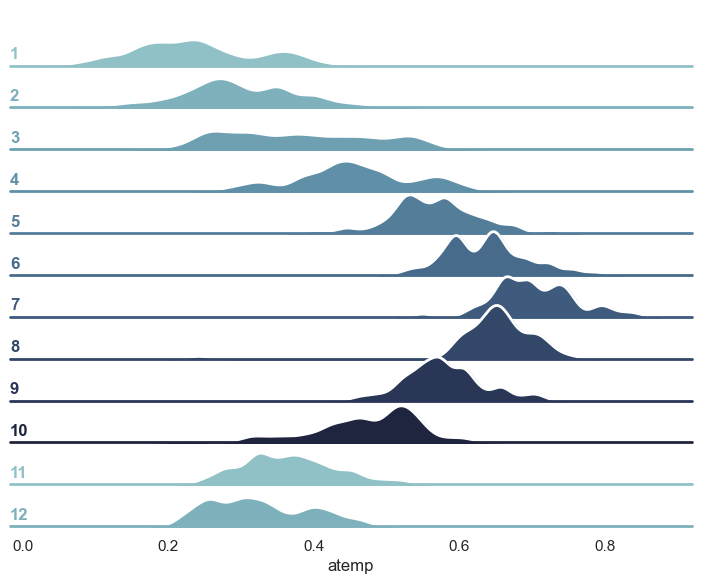

In [108]:
spectral_plot(df_bike, 'mnth', 'atemp')


/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)


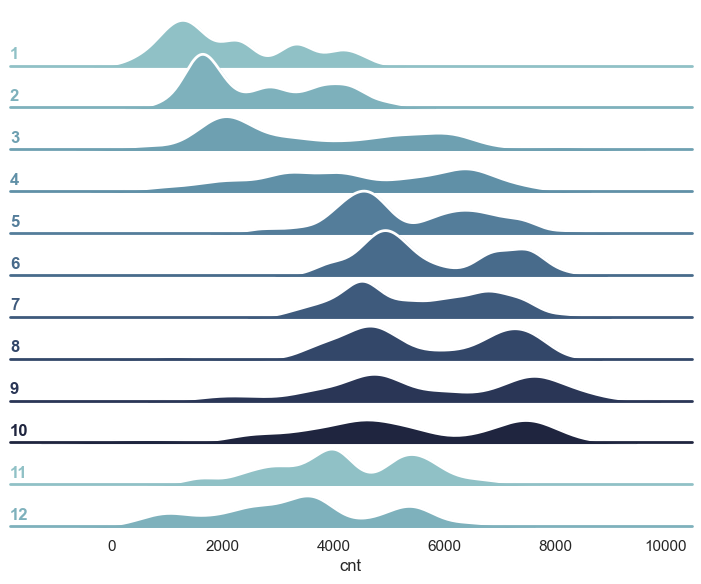

In [109]:
spectral_plot(df_bike, 'mnth', 'cnt')


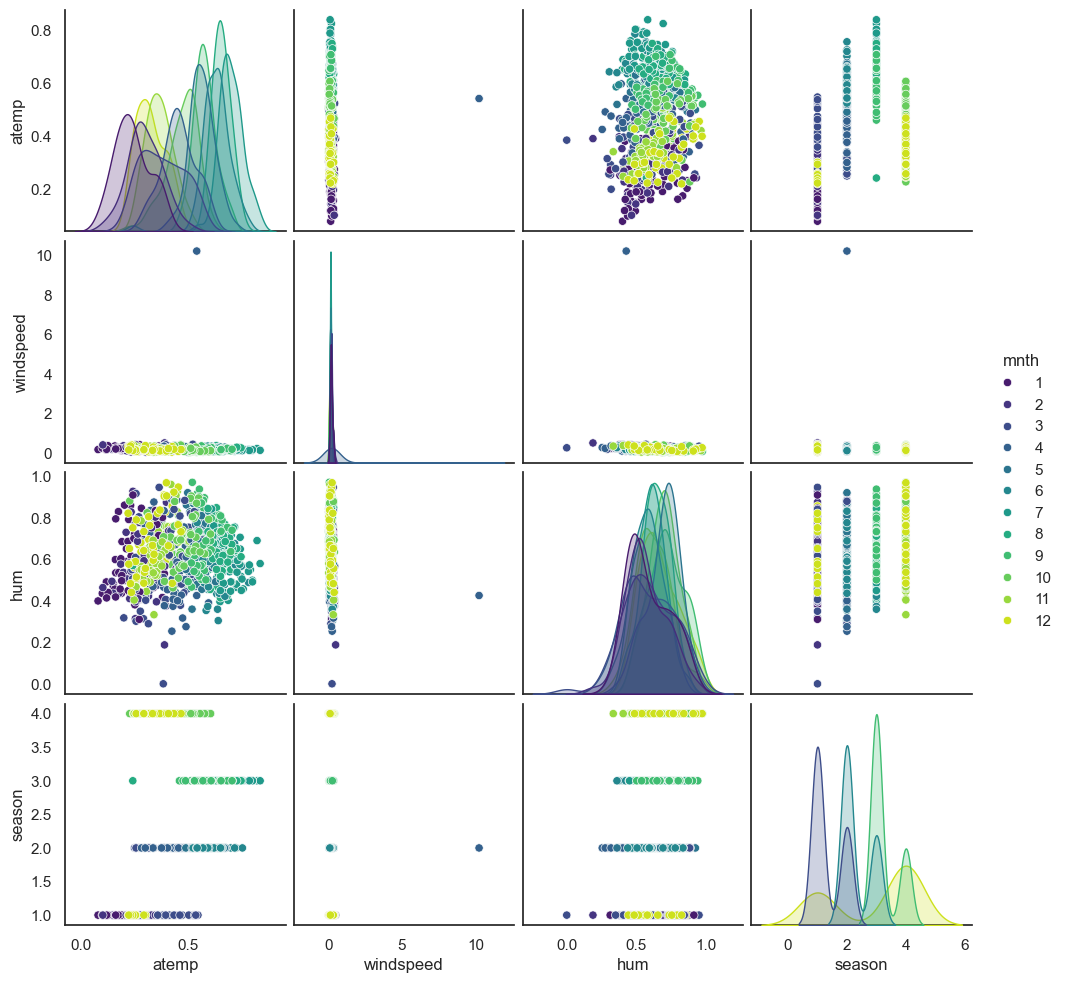

In [110]:
numeric_cols = ['atemp', 'windspeed', 'hum', 'season', 'mnth']
sns.pairplot(df_bike[numeric_cols], hue='mnth', palette=sns.color_palette("viridis", n_colors=12))
plt.show()


In [111]:
df_no_target = df_bike[['season', 'yr', 'mnth', 'weekday', 'workingday', 'schoolday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']]


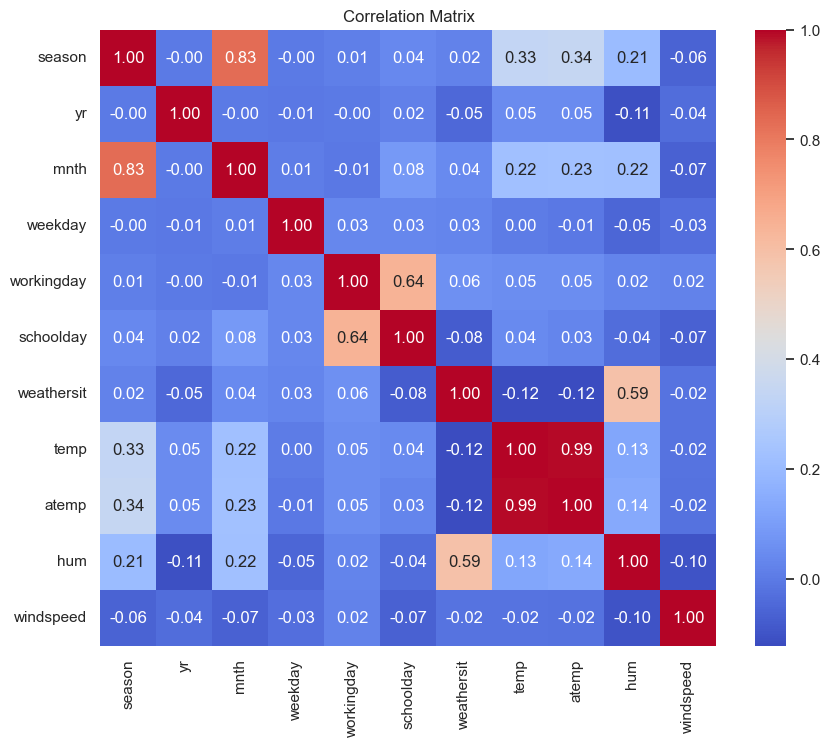

In [112]:
corr_matrix = df_no_target.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Correlation Matrix")
plt.show()


In [113]:
df_no_target = df_no_target.fillna(df_no_target.mean())


/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_96019/1511532871.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_no_target = df_no_target.fillna(df_no_target.mean())


In [114]:
df_no_target.head()


,season,yr,mnth,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446
1,1,0,1,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539
2,1,0,1,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309
3,1,0,1,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296
4,1,0,1,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900


In [115]:
data = df_no_target.values


In [116]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(data)


In [117]:
df_bike[['umap0', 'umap1']] = embedding


In [118]:
df_bike.head()


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,schoolday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weekday_filled,schoolday_filled,temp_segment,atemp_segment,windspeed_segment,umap0,umap1
0,1,2011-01-01,1,0,1,0,6.0,0,0.0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,6.0,0.0,Low,Low,Very Low,10.749410,-2.748708
1,2,2011-01-02,1,0,1,0,0.0,0,0.0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,0.0,0.0,Low,Low,Low,9.202633,6.564429
2,3,2011-01-03,1,0,1,0,1.0,1,1.0,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,1.0,1.0,Very Low,Very Low,Low,11.227229,9.059534
3,4,2011-01-04,1,0,1,0,2.0,1,1.0,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2.0,1.0,Very Low,Low,Very Low,11.224706,9.396067
4,5,2011-01-05,1,0,1,0,3.0,1,1.0,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,3.0,1.0,Low,Low,Very Low,11.072268,10.124049


:Scatter   [umap0]   (umap1,cnt)
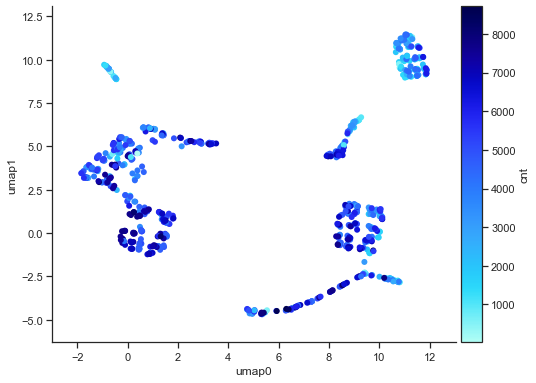

In [119]:
df_bike.hvplot.scatter(x='umap0', y='umap1', c='cnt', height=500, width=600)


:Scatter   [umap0]   (umap1,atemp)
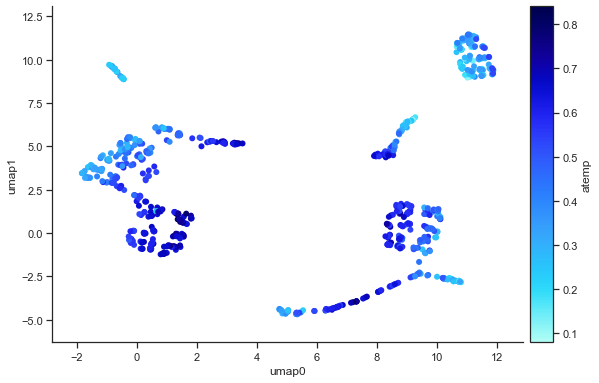

In [120]:
df_bike.hvplot.scatter(x='umap0', y='umap1', c='atemp', height=500)


:Scatter   [umap0]   (umap1,mnth)
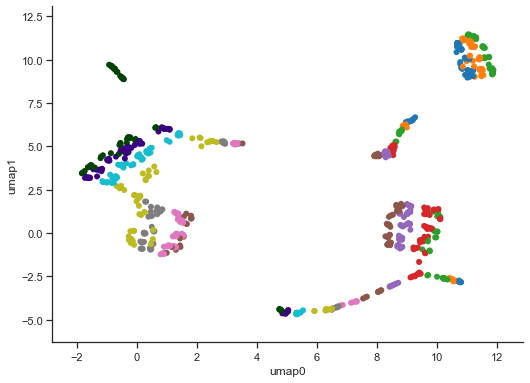

In [121]:
df_bike.hvplot.scatter(x='umap0', y='umap1', c='mnth', height=500)


### `Schoolday`: dealing with unknown values


In [123]:
# define weekend - weekends are not schooldays, we can use this information to sort some of the unknowns
weekend = df_bike['weekday'].isin([6.0, 0.0])


In [124]:
# use the resuls to fill the unknown values in schoolday with information from weekend
df_bike.loc[weekend & df_bike['schoolday'].isna(), 'schoolday'] = False


/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_96019/313200738.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'False' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_bike.loc[weekend & df_bike['schoolday'].isna(), 'schoolday'] = False


In [125]:
# count schooldays to see if unkowns diminished
counts_schoolday = df_bike['schoolday'].value_counts(dropna=False)
counts_schoolday


schoolday
0.0    319
1.0    209
NaN    203
Name: count, dtype: int64

In [126]:
# This is so that there are no "False" values, only 1 and 0
df_bike['schoolday'] = df_bike['schoolday'].replace({False: 0, True: 1})


/var/folders/g0/990px7q94zg1mm5vxhtzn72h0000gn/T/ipykernel_96019/2376529088.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bike['schoolday'] = df_bike['schoolday'].replace({False: 0, True: 1})


In [127]:
# we can also assume that august is part of the summer holidays for schools

# Ensure dtetime is datetime
df_bike['dteday'] = pd.to_datetime(df_bike['dteday'])

# This is a boolean Series: True if month == 8, else False
mask_august = (df_bike['dteday'].dt.month == 8)


In [128]:
# create a mask for the unknown values of schoolday
mask_schoolday_nan = df_bike['schoolday'].isna()

# Now combine both boolean masks with &
df_bike.loc[mask_august & mask_schoolday_nan, 'schoolday'] = 0


In [129]:
# count schooldays to see if unkowns diminished
counts_schoolday = df_bike['schoolday'].value_counts(dropna=False)
counts_schoolday


schoolday
0.0    332
1.0    209
NaN    190
Name: count, dtype: int64

In [130]:
# repeat the process for july, since this is also a month we can assume is summer holidays
mask_july = (df_bike['dteday'].dt.month == 7)


In [131]:
# Now combine both boolean masks with &
df_bike.loc[mask_july & mask_schoolday_nan, 'schoolday'] = 0


In [132]:
counts_schoolday = df_bike['schoolday'].value_counts(dropna=False)
counts_schoolday


schoolday
0.0    333
1.0    209
NaN    189
Name: count, dtype: int64

### School-day feature decision


# 2. Data Preparation


We can drop `schooldays` since it has too many missing values and the information in this column can be provided by similar columns. It has a high correlation with `workingday`. We can also drop `temp` since it has a 99% correlation with `atemp` and we consider `atemp` to be more useful since it is the real feel temperature.  
Delete also all the columns created for the purposes of data understanding.  
Another strong correlation we should consider is `mnth` and `season`.  
We will not replace the NaN values in the column `weekday` with the mean yet so we don't cause leakage. This will be done after splitting the data for train and test when applying the models.


In [136]:
df_bike = df_bike.drop([
    'schoolday', 'temp', 'casual', 'registered', 
    'atemp_segment', 'temp_segment', 'windspeed_segment', 'weekday_filled', 
    'schoolday_filled', 'instant', 'umap0', 'umap1'
], axis='columns')


In [137]:
df_bike.to_csv('data/bike_output.csv', index=False)
